# 3. Model Comparison — YOLO Pose

Benchmark all **5 YOLO Pose models** on the extracted keypoint data from notebook 2 and choose the best one for push-up pose estimation.

| Group | Models |
|---|---|
| YOLOv8 Pose | `yolov8n-pose` · `yolov8s-pose` |
| YOLO11 Pose | `yolo11n-pose` · `yolo11s-pose` · `yolo11m-pose` |

**Composite score:**  
`0.50 × feature_completeness + 0.30 × speed_score + 0.20 × elbow_quality`

Winner is saved to `keypoint_detector/best_model_choice.json`.

**Depends on:** `2.data_preparation.ipynb` completed.

In [1]:
import subprocess, sys
def install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

for pkg in ['ultralytics', 'opencv-python', 'pandas', 'matplotlib', 'tqdm', 'numpy']:
    install(pkg)
print('Dependencies ready.')

Dependencies ready.


In [2]:
import cv2, json, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from tqdm import tqdm
from ultralytics import YOLO

# ── Paths ─────────────────────────────────────────────────────────────────────
ROOT      = Path('..').resolve()
KD_DIR    = ROOT / 'keypoint_detector'
KPS_DIR   = KD_DIR / 'data' / 'keypoints'
CACHE_DIR = KD_DIR / 'eval_cache'
CACHE_DIR.mkdir(parents=True, exist_ok=True)

PD_DIR     = ROOT / 'person_detector'
FRAMES_DIR = PD_DIR / 'data' / 'frames'

POSE_MODELS = ['yolov8n-pose.pt', 'yolov8s-pose.pt',
               'yolo11n-pose.pt', 'yolo11s-pose.pt', 'yolo11m-pose.pt']

FEATURE_COLS = [
    'left_elbow_angle', 'right_elbow_angle', 'elbow_symmetry',
    'left_hip_angle',   'right_hip_angle',
    'body_straightness', 'shoulder_height', 'hip_height'
]

# ── Check that notebook 2 ran ─────────────────────────────────────────────────
available_models = [m for m in POSE_MODELS
                    if (KPS_DIR / m.replace('.pt','')).exists() and
                    any((KPS_DIR / m.replace('.pt','')).glob('*.json'))]
print(f'Extracted keypoints found for {len(available_models)}/{len(POSE_MODELS)} models:')
for m in available_models:
    n = len(list((KPS_DIR/m.replace('.pt','')).glob('*.json')))
    print(f'  {m}: {n} video files')

if not available_models:
    raise RuntimeError('No keypoint data found — run notebook 2 first!')

Extracted keypoints found for 5/5 models:
  yolov8n-pose.pt: 152 video files
  yolov8s-pose.pt: 152 video files
  yolo11n-pose.pt: 152 video files
  yolo11s-pose.pt: 152 video files
  yolo11m-pose.pt: 152 video files


## 3.1 Shared Helpers

In [3]:
def load_model_records(model_name: str) -> pd.DataFrame:
    """
    Load all per-frame records from keypoint JSON files.
    Returns a DataFrame with feature columns + label, video, detected.
    """
    model_dir = KPS_DIR / model_name.replace('.pt', '')
    rows = []
    for jf in sorted(model_dir.glob('*.json')):
        records = json.loads(jf.read_text())
        for r in records:
            row = {
                'video'   : jf.stem,
                'frame'   : r['frame'],
                'label'   : r['label'],
                'detected': r['keypoints'] is not None,
            }
            if r['features']:
                row.update(r['features'])
            rows.append(row)
    df = pd.DataFrame(rows)
    for col in FEATURE_COLS:
        if col not in df.columns:
            df[col] = np.nan
    return df


def feature_completeness(df: pd.DataFrame) -> float:
    """Fraction of detected frames where ALL 8 features are non-null."""
    detected = df[df.detected]
    if len(detected) == 0: return 0.0
    complete = detected[FEATURE_COLS].notna().all(axis=1).sum()
    return float(complete / len(detected))


def elbow_quality(df: pd.DataFrame) -> float:
    """Fraction of detected frames with BOTH elbow angles valid."""
    detected = df[df.detected]
    if len(detected) == 0: return 0.0
    both = (detected['left_elbow_angle'].notna() &
            detected['right_elbow_angle'].notna()).sum()
    return float(both / len(detected))


print('Helpers ready.')

Helpers ready.


## 3.2 Speed Benchmark

Measure real inference latency on a sample batch of 50 frames.

In [4]:
BENCH_CACHE = CACHE_DIR / 'speed_bench.json'

if BENCH_CACHE.exists():
    speed_results = json.loads(BENCH_CACHE.read_text())
    print('[cache] Loaded speed results.')
else:
    # Collect 50 sample frames for benchmarking
    import random; random.seed(42)
    all_frames = (sorted((FRAMES_DIR/'correct').rglob('*.jpg')) +
                  sorted((FRAMES_DIR/'wrong').rglob('*.jpg')))
    bench_frames = random.sample(all_frames, min(50, len(all_frames)))

    speed_results = {}
    for model_name in POSE_MODELS:
        model  = YOLO(model_name)
        times  = []
        for fp in tqdm(bench_frames, desc=f'Speed: {model_name}'):
            img = cv2.imread(str(fp))
            if img is None: continue
            t0 = time.perf_counter()
            model(img, conf=0.5, verbose=False)
            times.append((time.perf_counter() - t0) * 1000)

        speed_results[model_name] = {
            'avg_ms': round(float(np.mean(times)), 1),
            'p50_ms': round(float(np.percentile(times, 50)), 1),
            'p95_ms': round(float(np.percentile(times, 95)), 1),
        }
        print(f'  {model_name}: avg={speed_results[model_name]["avg_ms"]}ms')
        del model

    BENCH_CACHE.write_text(json.dumps(speed_results, indent=2))
    print('Speed results cached.')

df_speed = pd.DataFrame(speed_results).T.reset_index().rename(columns={'index':'model'})
print(df_speed.to_string(index=False))

Speed: yolov8n-pose.pt: 100%|██████████| 50/50 [00:02<00:00, 20.87it/s]


  yolov8n-pose.pt: avg=44.3ms


Speed: yolov8s-pose.pt: 100%|██████████| 50/50 [00:04<00:00, 12.20it/s]


  yolov8s-pose.pt: avg=80.6ms


Speed: yolo11n-pose.pt: 100%|██████████| 50/50 [00:02<00:00, 21.55it/s]


  yolo11n-pose.pt: avg=45.2ms


Speed: yolo11s-pose.pt: 100%|██████████| 50/50 [00:04<00:00, 11.76it/s]


  yolo11s-pose.pt: avg=83.6ms


Speed: yolo11m-pose.pt: 100%|██████████| 50/50 [00:08<00:00,  6.16it/s]

  yolo11m-pose.pt: avg=160.8ms
Speed results cached.
          model  avg_ms  p50_ms  p95_ms
yolov8n-pose.pt    44.3    38.6    61.5
yolov8s-pose.pt    80.6    75.1   102.7
yolo11n-pose.pt    45.2    41.2    55.8
yolo11s-pose.pt    83.6    77.7   113.8
yolo11m-pose.pt   160.8   149.6   226.0


## 3.3 Quality Metrics from Extracted Data

In [5]:
quality_rows = []

for model_name in available_models:
    df = load_model_records(model_name)

    det_rate = df.detected.mean()
    feat_cmp = feature_completeness(df)
    el_qual  = elbow_quality(df)

    # Elbow angle plausibility: how often is angle in valid pushup range [30°, 180°]
    detected = df[df.detected]
    l_valid  = ((detected['left_elbow_angle']  >= 30) &
                (detected['left_elbow_angle']  <= 180)).mean() if len(detected) > 0 else 0
    r_valid  = ((detected['right_elbow_angle'] >= 30) &
                (detected['right_elbow_angle'] <= 180)).mean() if len(detected) > 0 else 0
    angle_valid = (l_valid + r_valid) / 2

    quality_rows.append({
        'model'              : model_name.replace('.pt',''),
        'det_rate'           : round(det_rate, 3),
        'feat_completeness'  : round(feat_cmp, 3),
        'elbow_quality'      : round(el_qual, 3),
        'angle_validity'     : round(angle_valid, 3),
        'n_frames'           : len(df),
    })

df_qual = pd.DataFrame(quality_rows)
print(df_qual.to_string(index=False))

       model  det_rate  feat_completeness  elbow_quality  angle_validity  n_frames
yolov8n-pose     0.975              0.975          0.993           0.990      1858
yolov8s-pose     0.995              0.917          0.983           0.978      1858
yolo11n-pose     0.982              0.929          0.965           0.954      1858
yolo11s-pose     0.997              0.821          0.936           0.956      1858
yolo11m-pose     0.998              0.940          0.983           0.987      1858


## 3.4 Composite Scoring & Ranking

In [6]:
def normalise_col(series):
    """Min-max normalise to [0,1] (higher = better)."""
    mn, mx = series.min(), series.max()
    return (series - mn) / (mx - mn + 1e-9)


# Merge speed and quality
df_all = df_qual.copy()
df_all['avg_ms'] = df_all['model'].map(
    {k.replace('.pt',''): v['avg_ms'] for k,v in speed_results.items()}
)

# Speed score: lower ms = better (invert)
df_all['speed_score'] = normalise_col(1.0 / (df_all['avg_ms'] + 1e-9))
df_all['feat_score']  = normalise_col(df_all['feat_completeness'])
df_all['elbow_score'] = normalise_col(df_all['elbow_quality'])

# Composite score
df_all['composite'] = (0.50 * df_all['feat_score'] +
                       0.30 * df_all['speed_score'] +
                       0.20 * df_all['elbow_score'])

df_all = df_all.sort_values('composite', ascending=False).reset_index(drop=True)
df_all['rank'] = df_all.index + 1

print('=== Final Rankings ===')
print(df_all[['rank','model','feat_completeness','elbow_quality','avg_ms','composite']]
      .to_string(index=False))

best_row = df_all.iloc[0]

=== Final Rankings ===
 rank        model  feat_completeness  elbow_quality  avg_ms  composite
    1 yolov8n-pose              0.975          0.993    44.3   1.000000
    2 yolo11n-pose              0.929          0.965    45.2   0.744159
    3 yolov8s-pose              0.917          0.983    80.6   0.590112
    4 yolo11m-pose              0.940          0.983   160.8   0.551276
    5 yolo11s-pose              0.821          0.936    83.6   0.105344


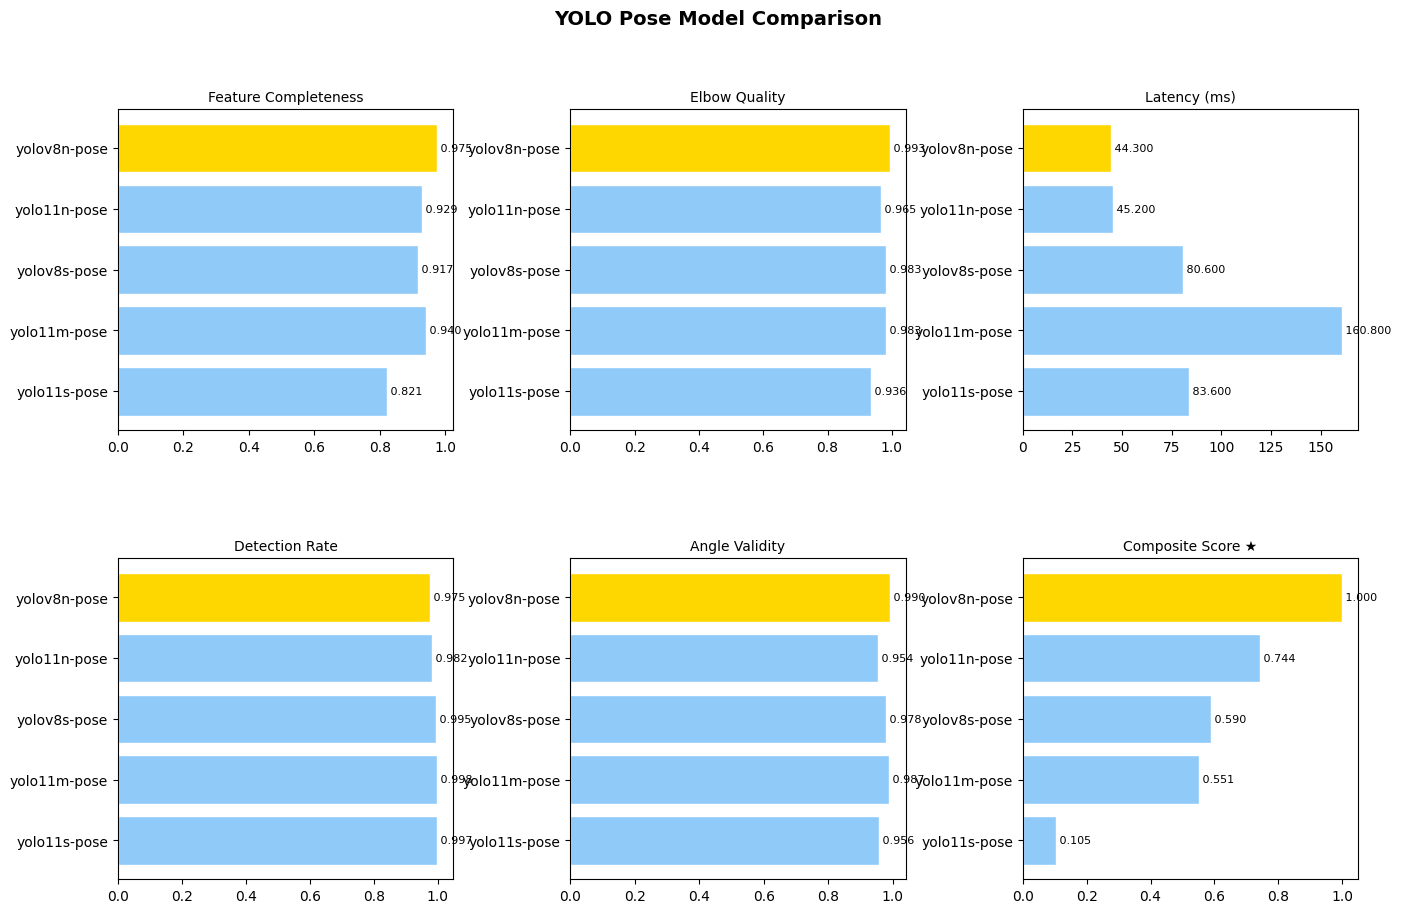


🏆 Winner: yolov8n-pose  (composite=1.000)


In [7]:
# ── Visualise rankings ────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

models = df_all['model'].tolist()
colors = ['#FFD700' if i==0 else '#90CAF9' for i in range(len(models))]

metrics = [
    ('feat_completeness', 'Feature Completeness', (0,0)),
    ('elbow_quality',     'Elbow Quality',        (0,1)),
    ('avg_ms',            'Latency (ms)',          (0,2)),
    ('det_rate',          'Detection Rate',        (1,0)),
    ('angle_validity',    'Angle Validity',        (1,1)),
    ('composite',         'Composite Score ★',     (1,2)),
]

for col, title, (r,c) in metrics:
    ax = fig.add_subplot(gs[r,c])
    vals = df_all[col].tolist()
    ax.barh(models, vals, color=colors, edgecolor='white')
    for i, v in enumerate(vals):
        ax.text(v, i, f' {v:.3f}', va='center', fontsize=8)
    ax.set_title(title, fontsize=10)
    ax.invert_yaxis()

fig.suptitle('YOLO Pose Model Comparison', fontsize=14, fontweight='bold')
plt.show()
print(f'\n🏆 Winner: {best_row.model}  (composite={best_row.composite:.3f})')

## 3.5 Save Best Model Choice

In [11]:
best_name = str(best_row['model'])      # e.g. 'yolo11m-pose'
best_pt   = best_name + '.pt'           # e.g. 'yolo11m-pose.pt'

top3 = []
for _, row in df_all.head(3).iterrows():
    top3.append({'name': row['model'], 'model_id': row['model']+'.pt',
                 'score': round(row['composite'], 4),
                 'feat_completeness': round(row['feat_completeness'], 4),
                 'elbow_quality':     round(row['elbow_quality'], 4),
                 'avg_ms':            round(row.get('avg_ms', 0), 1)})

choice = {
    'model_id'        : best_pt,
    'score'           : round(float(best_row['composite']), 4),
    'feat_completeness': round(float(best_row['feat_completeness']), 4),
    'elbow_quality'   : round(float(best_row['elbow_quality']), 4),
    'avg_ms'          : round(float(best_row.get('avg_ms', 0)), 1),
    'top3_models'     : top3,
}

out_path = KD_DIR / 'best_model_choice.json'
out_path.write_text(json.dumps(choice, indent=2))
print(f'Saved to: {out_path}')
print(json.dumps(choice, indent=2))

Saved to: /Users/haleytran/Downloads/pushup_judge/keypoint_detector/best_model_choice.json
{
  "model_id": "yolov8n-pose.pt",
  "score": 1.0,
  "feat_completeness": 0.975,
  "elbow_quality": 0.993,
  "avg_ms": 44.3,
  "top3_models": [
    {
      "name": "yolov8n-pose",
      "model_id": "yolov8n-pose.pt",
      "score": 1.0,
      "feat_completeness": 0.975,
      "elbow_quality": 0.993,
      "avg_ms": 44.3
    },
    {
      "name": "yolo11n-pose",
      "model_id": "yolo11n-pose.pt",
      "score": 0.7442,
      "feat_completeness": 0.929,
      "elbow_quality": 0.965,
      "avg_ms": 45.2
    },
    {
      "name": "yolov8s-pose",
      "model_id": "yolov8s-pose.pt",
      "score": 0.5901,
      "feat_completeness": 0.917,
      "elbow_quality": 0.983,
      "avg_ms": 80.6
    }
  ]
}


## 3.6 Per-Class Quality Check

Verify that the best model handles both correct and wrong form equally.

In [9]:
df_best = load_model_records(best_pt)

print(f'=== Per-class statistics — {best_pt} ===')
for label in ['correct', 'wrong']:
    sub = df_best[df_best.label == label]
    det = sub[sub.detected]
    print(f'\n{label.upper()}: {len(sub)} frames, {len(det)} detected ({100*len(det)/max(1,len(sub)):.1f}%)')
    if len(det) > 0:
        print(det[['left_elbow_angle','right_elbow_angle','body_straightness']]
              .describe().round(2).to_string())

=== Per-class statistics — yolov8n-pose.pt ===

CORRECT: 813 frames, 799 detected (98.3%)
       left_elbow_angle  right_elbow_angle  body_straightness
count            799.00             799.00             792.00
mean             145.73             145.06               0.04
std               32.39              30.27               0.03
min               13.73               7.14               0.00
25%              130.59             129.35               0.01
50%              160.17             156.90               0.03
75%              167.69             166.31               0.05
max              179.91             179.67               0.20

WRONG: 1045 frames, 1013 detected (96.9%)
       left_elbow_angle  right_elbow_angle  body_straightness
count           1011.00            1002.00             985.00
mean             148.26             149.84               0.05
std               28.43              26.69               0.04
min                0.96               4.14               0.00

/var/folders/cd/w5n36_jx0bg5lr_cx88kv7yw0000gn/T/ipykernel_17596/1147481533.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([correct_el, wrong_el],


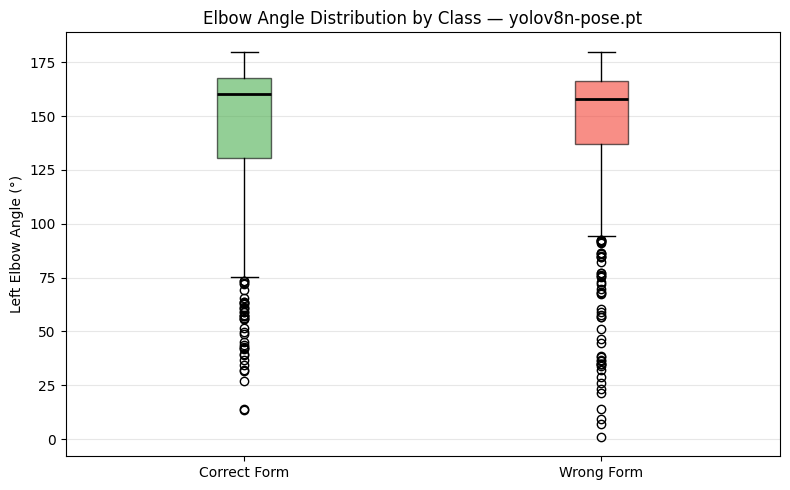

In [10]:
# Elbow angle by class (violin / boxplot)
correct_el = df_best[(df_best.label=='correct') & df_best.detected]['left_elbow_angle'].dropna()
wrong_el   = df_best[(df_best.label=='wrong')   & df_best.detected]['left_elbow_angle'].dropna()

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot([correct_el, wrong_el],
           labels=['Correct Form', 'Wrong Form'],
           patch_artist=True,
           boxprops=dict(facecolor='#E0E0E0'),
           medianprops=dict(color='black', linewidth=2))
colors = ['#4CAF50','#F44336']
for patch, c in zip(ax.patches, colors):
    patch.set_facecolor(c); patch.set_alpha(0.6)
ax.set_ylabel('Left Elbow Angle (°)')
ax.set_title(f'Elbow Angle Distribution by Class — {best_pt}')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 3.7 Summary

**Next:** `4.model_evaluation.ipynb` — deep evaluation of the winning pose model, visualize keypoint overlays, and save the final model to `models/best_model/`.